## 🌲 What is Pinecone Database?

### 📌 Definition

* **Pinecone** is a **managed vector database service**.
* It is designed to store, index, and search **high-dimensional vector embeddings** efficiently.
* Commonly used in **AI applications**, especially those involving **semantic search** and **machine learning models**.

---

### 🧠 Key Concept: Vector Embeddings

* Data (text, images, audio) is converted into **numerical vectors**.
* These vectors capture **meaning and relationships**.
* Example: Similar sentences → similar vectors.

---

### ⚙️ Core Features

* **Similarity Search**

  * Finds closest vectors using metrics like cosine similarity.
* **Scalable Infrastructure**

  * Automatically handles large datasets.
* **Real-time Updates**

  * Insert, update, delete vectors instantly.
* **Fully Managed**

  * No need to manage servers or infrastructure.

---

### 🚀 How It Works (Simplified)

1. Convert data into embeddings (using models like OpenAI API).
2. Store embeddings in Pinecone.
3. Query with a vector.
4. Pinecone returns **most similar results**.

---

### 🧩 Use Cases

* 🔍 Semantic search (search by meaning, not keywords)
* 🤖 Chatbots & AI assistants
* 📄 Document retrieval (RAG systems)
* 🛍️ Recommendation systems
* 🖼️ Image similarity search

---

### 📊 Advantages

* Fast and accurate similarity matching
* Handles billions of vectors
* Easy API integration
* Optimized for AI workloads

---

### ⚠️ Limitations

* Not a traditional relational database
* Requires understanding of embeddings
* Can be costly at scale

---

### 🆚 Compared to Traditional Databases

| Feature    | Traditional DB        | Pinecone             |
| ---------- | --------------------- | -------------------- |
| Data Type  | Structured (tables)   | Vector embeddings    |
| Query Type | SQL queries           | Similarity search    |
| Use Case   | Transactions, records | AI & semantic search |

---

### 📝 Summary

* Pinecone is a **specialized database for vectors**.
* It powers **modern AI applications** by enabling fast similarity search.
* Essential for systems using **embeddings and large-scale search**.

---


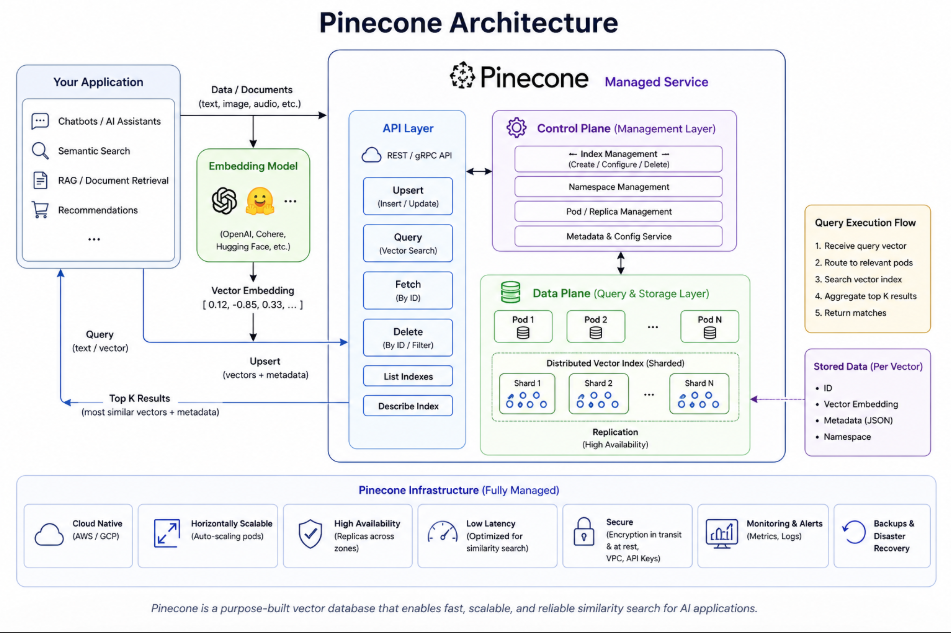

Here is the high level overview of the above architecture.

---

## 🧩 1. Application Layer (Left Side)

* This is **your app** (chatbot, search engine, recommendation system).
* Examples:

  * Chatbots / AI assistants
  * Semantic search
  * RAG (Retrieval-Augmented Generation)

👉 The app sends:

* **Data** (documents, images, etc.)
* **Queries** (what the user is searching for)

---

## 🧠 2. Embedding Model

* Before storing/searching, data is converted into **vector embeddings**.
* Done using models like OpenAI API, Cohere, Hugging Face.

👉 Output:

* A list of numbers (vector) representing meaning
  Example: `[0.12, -0.85, 0.33, ...]`

---

## 🔌 3. API Layer (Pinecone Interface)

* This is how your app communicates with Pinecone

### Main API operations:

* **Upsert** → Store or update vectors
* **Query** → Search similar vectors
* **Fetch** → Retrieve by ID
* **Delete** → Remove data
* **List / Describe Index** → Manage indexes

👉 Think of this as the **entry point** into Pinecone.

---

## ⚙️ 4. Control Plane (Management Layer)

* Handles **configuration and management**, not actual data.

### Responsibilities:

* Index creation & deletion
* Namespace management
* Pod/replica control (scaling)
* Metadata configuration

👉 Like a **brain** controlling the system.

---

## 💾 5. Data Plane (Storage + Search Layer)

This is where the **real work happens**.

### Key components:

* **Pods** → Compute units handling storage & queries
* **Distributed Vector Index** → Data is split into shards
* **Replication** → Copies for high availability

👉 Ensures:

* Fast search
* Scalability
* Reliability

---

## 🔍 6. Query Execution Flow (Right Side)

When you search:

1. Query is converted into a **vector**
2. Routed to relevant **pods**
3. Pinecone searches the **vector index**
4. Finds **Top K similar vectors**
5. Returns results (with metadata)

👉 Output: Most relevant matches

---

## 🗂️ 7. Stored Data Format

Each stored item includes:

* **ID**
* **Vector embedding**
* **Metadata (JSON)**
* **Namespace**

---

## ☁️ 8. Infrastructure (Bottom Layer)

Pinecone is fully managed and provides:

* Cloud-based (AWS / GCP)
* Auto-scaling
* High availability
* Low latency
* Security (encryption, API keys)
* Monitoring & backups

---

## 🔁 Overall Flow (Simple)

1. App → sends data
2. Data → converted to vectors
3. Vectors → stored in Pinecone
4. Query → converted to vector
5. Pinecone → finds similar vectors
6. Results → returned to app

---

## 📝 One-Line Summary

👉 Pinecone architecture separates **management (control plane)** and **data processing (data plane)** to deliver **fast, scalable vector search for AI applications**.

---


**Full journey of a query in Pinecone-based systems**, step by step, from the moment a user types something to the final answer they see.

I’ll keep it **deep and sequential**, like a system trace.

---

# 🔄 End-to-End Flow: User Query → Final Answer

---

## 🧍 1. User Enters a Query

* A user types something like:

  > “Best budget laptops for students”

* This happens inside an application:

  * Chatbot
  * Search engine
  * AI assistant

👉 At this point, it’s just **plain text**, not usable for vector search.

---

## 🧠 2. Query is Converted into an Embedding

* The application sends the query to an embedding model (e.g., OpenAI API).

### What happens internally:

* The model analyzes:

  * Meaning
  * Context
  * Relationships between words

* It outputs a **vector (array of numbers)**:

  ```
  Query → [0.21, -0.67, 0.45, ..., 0.09]
  ```

👉 This vector represents the **semantic meaning** of the query.

---

## 📦 3. (Background) Data Was Already Prepared

Before any query happens, the system has already done this:

### Data ingestion pipeline:

1. Raw data (documents, products, etc.)
2. Converted into embeddings
3. Stored in Pinecone

Each stored record looks like:

```
{
  id: "doc123",
  vector: [0.18, -0.72, ...],
  metadata: {
    title: "Best laptops under $1000",
    category: "electronics"
  }
}
```

👉 This is important: Pinecone **does NOT store raw text as primary search data**, it stores vectors.

---

## 🔌 4. Query Sent to Pinecone API

* The app sends the query vector to Pinecone via API.

### Example request:

* Index name
* Query vector
* Top K (e.g., 5 results)
* Optional filters (metadata)

👉 This goes into Pinecone’s **API Layer**.

---

## ⚙️ 5. Control Plane Handles Routing

Inside Pinecone:

* The **Control Plane**:

  * Identifies the correct index
  * Checks configuration
  * Routes query to the right **pods**

👉 No actual searching happens here — just orchestration.

---

## 💾 6. Data Plane Executes the Search

Now the real work begins.

### Step-by-step inside Data Plane:

#### a. Query reaches relevant Pods

* Pods = compute + storage units
* Each pod holds part of the data (shards)

---

#### b. Vector Comparison Begins

* Pinecone compares query vector with stored vectors using:

### Common similarity metrics:

* Cosine similarity
* Dot product
* Euclidean distance

👉 Example:

```
Query vector vs Stored vector → similarity score = 0.92
```

---

#### c. Approximate Nearest Neighbor (ANN) Search

* Pinecone doesn’t scan everything linearly (too slow).
* Uses optimized indexing (like HNSW or similar structures).

👉 This allows:

* Searching **millions/billions of vectors in milliseconds**

---

#### d. Top-K Selection

* System selects top K most similar vectors:

```
Top 3:
1. Score: 0.95 → "Best laptops for students 2025"
2. Score: 0.92 → "Affordable laptops guide"
3. Score: 0.89 → "Budget-friendly notebooks"
```

---

## 📤 7. Results Returned from Pinecone

* Pinecone sends back:

  * IDs
  * Similarity scores
  * Metadata

Example:

```
[
  {id: "doc1", score: 0.95, metadata: {...}},
  {id: "doc2", score: 0.92, metadata: {...}}
]
```

👉 Note: It does NOT generate natural language answers.

---

## 🧩 8. Post-Processing in Application

Now your application takes over again.

### Possible actions:

* Fetch full documents from database
* Rank/filter results further
* Combine results

---

## 🤖 9. (Optional but Common) LLM Generates Final Answer

In modern systems (RAG architecture):

* The retrieved data is sent to an LLM (e.g., OpenAI API or GPT models)

### Example:

Input to LLM:

* User query
* Retrieved documents

Output:

> “Here are the best budget laptops for students: …”

👉 This is where **human-like answers are generated**.

---

## 🧾 10. Final Answer Sent to User

* The application formats the response:

  * Text
  * Links
  * Recommendations

* User sees the final result.

---

# 🔁 Full Flow Summary (Compressed)

```
User Query (text)
   ↓
Embedding Model → Query Vector
   ↓
Pinecone API
   ↓
Control Plane (routing)
   ↓
Data Plane (vector search)
   ↓
Top-K Similar Results
   ↓
Application Processing
   ↓
LLM (optional)
   ↓
Final Answer to User
```

---

# 🧠 Deep Understanding Insights

### 🔑 Key Idea 1: Meaning over Keywords

* Traditional search → keyword match
* Pinecone → semantic similarity

---

### 🔑 Key Idea 2: Separation of Responsibilities

* Embedding model → understanding
* Pinecone → retrieval
* LLM → generation

---

### 🔑 Key Idea 3: Speed Comes from Indexing

* ANN algorithms avoid brute-force search
* That’s why it scales massively

---

### 🔑 Key Idea 4: Pinecone is NOT the “Answer Generator”

* It only finds **relevant data**
* The “intelligence” comes from:

  * Embeddings
  * LLMs

---

# 📝 Final One-Line Understanding

👉 Pinecone acts as a **high-speed semantic memory system** that retrieves the most relevant information, which is then used by AI models to generate the final answer.

---
